> **Essential ML process for Intrusion Detection**
<br>` python  3.7.13    scikit-learn  1.0.2 `
<br>`numpy   1.19.5          pandas  1.3.5`

## 1.0 Import Libraries

In [1]:
import numpy
import pandas

from time import time

import os
data_path = '../data'  # Updated for Assignment folder structure

_import the local library_

In [2]:
# add parent folder path where lib folder is
import sys
if ".." not in sys.path:import sys; sys.path.insert(0, '..') 

In [3]:
from mylib import show_labels_dist, show_metrics, bias_var_metrics

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2.0 Import Dataset

In [4]:
# Using boosted Train and preprocessed Test

data_file = os.path.join(data_path, 'NSL_boosted-2.csv') 
train_df = pandas.read_csv(data_file)
print('Train Dataset: {} rows, {} columns'.format(train_df.shape[0], train_df.shape[1]))

data_file = os.path.join(data_path, 'NSL_ppTest.csv') 
test_df = pandas.read_csv(data_file)
print('Test Dataset: {} rows, {} columns'.format(test_df.shape[0], test_df.shape[1]))

Train Dataset: 63280 rows, 43 columns
Test Dataset: 22544 rows, 43 columns


***
**Data Preparation and EDA** (unique to this dataset)

* _Check column names of numeric attributes_

In [5]:
trnn = train_df.select_dtypes(include=['float64','int64']).columns
tstn = test_df.select_dtypes(include=['float64','int64']).columns
trndif = numpy.setdiff1d(trnn, tstn)
tstdif = numpy.setdiff1d(tstn, trnn)

print("Numeric features in the train_set that are not in the test_set: ",end='')
if len(trndif) > 0:
    print('\n',trndif)
else:
    print('None')

print("Numeric features in the test_set that are not in the train_set: ",end='')
if len(tstdif) > 0:
    print('\n',tstdif)
else:
    print('None')

print()
# correct any differences here

Numeric features in the train_set that are not in the test_set: None
Numeric features in the test_set that are not in the train_set: None



* _Check column names of categorical attributes_

In [6]:
trnn = train_df.select_dtypes(include=['object']).columns
tstn = test_df.select_dtypes(include=['object']).columns
trndif = numpy.setdiff1d(trnn, tstn)
tstdif = numpy.setdiff1d(tstn, trnn)

print("Categorical features in the train_set that are not in the test_set: ",end='')
if len(trndif) > 0:
    print('\n',trndif)
else:
    print('None')

print("Categorical features in the test_set that are not in the train_set: ",end='')
if len(tstdif) > 0:
    print('\n\t',tstdif)
else:
    print('None')

print()
# correct any differences here

Categorical features in the train_set that are not in the test_set: None
Categorical features in the test_set that are not in the train_set: None



* _Check for missing values_

In [7]:
cnt=0
print('Missing Values - Train Set')
for col in train_df.columns:
#    print(col, ' ::> ', len(combined_df[col].unique()))
    nnul = pandas.notnull(train_df[col]) 
    if (len(nnul)!=len(train_df)):
        cnt=cnt+1
        print('\t',col,':',(len(test_df)-len(nnul)),'null values')
print('Total',cnt,'features with null values')

cnt=0
print('Missing Values - Test Set')
for col in test_df.columns:
#    print(col, ' ::> ', len(combined_df[col].unique()))
    nnul = pandas.notnull(test_df[col]) 
    if (len(nnul)!=len(test_df)):
        cnt=cnt+1
        print('\t',col,':',(len(test_df)-len(nnul)),'null values')
print('Total',cnt,'features with null values')

# address missing values here

Missing Values - Train Set
Total 0 features with null values
Missing Values - Test Set
Total 0 features with null values


* _Quick visual check of unique values, deal with unique identifiers_

In [8]:
# Identify columns with only one value 
# or with number of unique values == number of rows
n_eq_one = []
n_eq_all = []

print('Unique value count: Train (',train_df.shape[0],'rows ) ~ Test(',test_df.shape[0],'rows )')
for col in train_df.columns:
    lctrn = len(train_df[col].unique())
    lctst = len(test_df[col].unique())
    print(col, ' ::> ', lctrn, ' ~ ', lctst)
    if (lctrn == 1) and (lctrn == lctst): 
        n_eq_one.append(train_df[col].name)
    if lctrn == train_df.shape[0]:
        n_eq_all.append(train_df[col].name)

Unique value count: Train ( 63280 rows ) ~ Test( 22544 rows )
duration  ::>  1657  ~  624
protocol_type  ::>  3  ~  3
service  ::>  70  ~  64
flag  ::>  11  ~  11
src_bytes  ::>  2553  ~  1149
dst_bytes  ::>  6633  ~  3650
land  ::>  2  ~  2
wrong_fragment  ::>  3  ~  3
urgent  ::>  3  ~  4
hot  ::>  24  ~  16
num_failed_logins  ::>  6  ~  5
logged_in  ::>  2  ~  2
num_compromised  ::>  49  ~  23
root_shell  ::>  2  ~  2
su_attempted  ::>  3  ~  3
num_root  ::>  44  ~  20
num_file_creations  ::>  28  ~  9
num_shells  ::>  3  ~  4
num_access_files  ::>  9  ~  5
num_outbound_cmds  ::>  1  ~  1
is_host_login  ::>  2  ~  2
is_guest_login  ::>  2  ~  2
count  ::>  511  ~  495
srv_count  ::>  489  ~  457
serror_rate  ::>  87  ~  88
srv_serror_rate  ::>  75  ~  82
rerror_rate  ::>  81  ~  90
srv_rerror_rate  ::>  63  ~  93
same_srv_rate  ::>  101  ~  75
diff_srv_rate  ::>  88  ~  99
srv_diff_host_rate  ::>  61  ~  84
dst_host_count  ::>  256  ~  256
dst_host_srv_count  ::>  256  ~  256
dst_ho

In [9]:
# Drop columns with only one value
if len(n_eq_one) > 0:
    print('Dropping single-valued features')
    print(n_eq_one)
    train_df.drop(n_eq_one, axis=1, inplace=True)
    test_df.drop(n_eq_one, axis=1, inplace=True)

# Drop or bin columns with number of unique values == number of rows
if len(n_eq_all) > 0:
    print('Dropping unique identifiers')
    print(n_eq_all)
    train_df.drop(n_eq_all, axis=1, inplace=True)
    test_df.drop(n_eq_all, axis=1, inplace=True)

# continue with featue selection / feature engineering

Dropping single-valued features
['num_outbound_cmds']


* _Check categorical feature values:<br>
differences will be resolved by one-hot encoding the combined test and train sets_

In [10]:
trnn = train_df.select_dtypes(include=['object']).columns
for col in trnn:
    tr = train_df[col].unique()
    ts = test_df[col].unique()
    trd = numpy.setdiff1d(tr, ts)
    tsd = numpy.setdiff1d(ts, tr)
    
    print(col,'::> ')
    print("\tUnique text values in the train_set that are not in the test_set: ",end='')
    if len(trd) > 0:
        print('\n\t',trd)
    else:
        print('None')
    
    print("\tUnique text values in the test_set that are not in the train_set: ",end='')
    if len(tsd) > 0:
        print('\n\t',tsd)
    else:
        print('None')

protocol_type ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None
service ::> 
	Unique text values in the train_set that are not in the test_set: 
	 ['aol' 'harvest' 'http_2784' 'http_8001' 'red_i' 'urh_i']
	Unique text values in the test_set that are not in the train_set: None
flag ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None
label ::> 
	Unique text values in the train_set that are not in the test_set: 
	 ['spy' 'warezclient']
	Unique text values in the test_set that are not in the train_set: None
atakcat ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None


* _Combine for processing classification target and text features_

In [11]:
combined_df = pandas.concat([train_df, test_df])
print('Combined Dataset: {} rows, {} columns'.format(
    combined_df.shape[0], combined_df.shape[1]))

Combined Dataset: 85824 rows, 42 columns


* _Classification Target feature:_
two columns of labels are available 
    * Two-class: Reduce the detailed attack labels to 'normal' or 'attack'
    * Multiclass: Use the category labels (atakcat)

In [12]:
combined_df['label'].value_counts()

label
normal             43383
neptune            25264
satan               2552
smurf               1988
ipsweep             1941
portsweep           1623
guess_passwd        1257
mscan               1046
warezmaster          954
back                 837
nmap                 820
apache2              774
processtable         719
teardrop             458
warezclient          445
snmpguess            364
saint                350
mailbomb             322
snmpgetattack        196
httptunnel           146
pod                  142
buffer_overflow       35
named                 25
ps                    22
multihop              21
sendmail              21
xterm                 20
rootkit               18
land                  16
xlock                 14
xsnoop                 8
ftp_write              7
imap                   6
loadmodule             6
phf                    6
perl                   5
worm                   4
sqlattack              4
udpstorm               4
spy                

In [13]:
combined_df['atakcat'].value_counts()

atakcat
benign    43383
dos       30524
probe      8332
r2l        3329
u2r         256
Name: count, dtype: int64

In [14]:
# Set the classification target
twoclass = False     # True or False

In [15]:
if twoclass:
# Two-class: Reduce the detailed attack labels to 'normal' or 'attack'
# new single column data structure is a [series]
    labels_df = combined_df['label'].copy()
    labels_df[labels_df != 'normal'] = 'attack'
else:
# Multiclass: Use the category labels (atakcat)
# new single column data structure is a [[dataframe]]
# rename the column and convert to a series for later
    labels_df = combined_df[['atakcat']].copy()
    labels_df.rename(columns={'atakcat':'label'}, inplace=True)
    labels_df = labels_df.squeeze('columns')

# drop target features 
combined_df.drop(['label'], axis=1, inplace=True)
combined_df.drop(['atakcat'], axis=1, inplace=True)

* _One-Hot Encoding the categorical (text) features_

In [16]:
# put the names into a python list - for pandas.get_dummies()
categori = combined_df.select_dtypes(include=['object']).columns
category_cols = categori.tolist()
print(category_cols)

['protocol_type', 'service', 'flag']


In [17]:
# generate a sorted list of unique values of categorical features
# we will get a new column for each one with get_dummies()

for col in categori:
    ul = numpy.sort(list(combined_df[col].unique()))
    print(col, ' ::> ', ul)
    print()

protocol_type  ::>  ['icmp' 'tcp' 'udp']

service  ::>  ['IRC' 'X11' 'Z39_50' 'aol' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf'
 'daytime' 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs'
 'exec' 'finger' 'ftp' 'ftp_data' 'gopher' 'harvest' 'hostnames' 'http'
 'http_2784' 'http_443' 'http_8001' 'imap4' 'iso_tsap' 'klogin' 'kshell'
 'ldap' 'link' 'login' 'mtp' 'name' 'netbios_dgm' 'netbios_ns'
 'netbios_ssn' 'netstat' 'nnsp' 'nntp' 'ntp_u' 'other' 'pm_dump' 'pop_2'
 'pop_3' 'printer' 'private' 'red_i' 'remote_job' 'rje' 'shell' 'smtp'
 'sql_net' 'ssh' 'sunrpc' 'supdup' 'systat' 'telnet' 'tftp_u' 'tim_i'
 'time' 'urh_i' 'urp_i' 'uucp' 'uucp_path' 'vmnet' 'whois']

flag  ::>  ['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']



In [18]:
# Apply to the list of Categorical columns (text fields)
features_df = pandas.get_dummies(combined_df, columns=category_cols)
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85824 entries, 0 to 22543
Columns: 121 entries, duration to flag_SH
dtypes: bool(84), float64(15), int64(22)
memory usage: 31.8 MB


In [19]:
# generate a list of numeric columns for scaling - After test // train split
numeri = combined_df.select_dtypes(include=['float64','int64']).columns
print(numeri.to_list())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


***
**<br>Create Test // Train Datasets**
> Normally we split the dataset into train 70 % // test 30 % like this
<br>`from sklearn.model_selection import train_test_split`
<br>`X_train, X_test, y_train, y_test = `
<br>`    train_test_split(features_df, labels_df, `
<br>`        test_size=0.3, stratify=labels_df, random_state=42)`

In [20]:
# Restore the train // test split: slice 1 Dataframe into 2 
features_train = features_df.iloc[:len(train_df),:].copy()    # X_train
features_train.reset_index(inplace=True, drop=True)
# pandas has a lot of rules about returning a 'view' vs. a copy from slice
# so we force it to create a new dataframe [avoiding SettingWithCopy Warning]
features_test = features_df.iloc[len(train_df):,:].copy()     # X_test
features_test.reset_index(inplace=True, drop=True)

# Restore the train // test split: slice 1 Series into 2 
labels_train = labels_df[:len(train_df)]               # y_train
labels_train.reset_index(inplace=True, drop=True)

labels_test = labels_df[len(train_df):]                # y_test
labels_test.reset_index(inplace=True, drop=True)

***
Next are standard steps for all datasets: _scaling, classifiers, results_

**Scaling** comes _after_ test // train split

In [21]:
# scaling the Numeric columns 
# StandardScaler range: -1 to 1, MinMaxScaler range: zero to 1

# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# sklearn docs say 
#   "Don't cheat - fit only on training data, then transform both"
#   fit() expects 2D array: reshape(-1, 1) for single col or (1, -1) single row

for i in numeri:
    arr = numpy.array(features_train[i])
    scale = MinMaxScaler().fit(arr.reshape(-1, 1))
    features_train[i] = scale.transform(arr.reshape(len(arr),1))

    arr = numpy.array(features_test[i])
    features_test[i] = scale.transform(arr.reshape(len(arr),1))

**<br>Classifier Selection**

In [22]:
# prepare list
models = []

##  --  Linear  --  ## 
#from sklearn.linear_model import LogisticRegression 
#models.append (("LogReg",LogisticRegression())) 
#from sklearn.linear_model import SGDClassifier 
#models.append (("StocGradDes",SGDClassifier())) 
#from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
#models.append(("LinearDA", LinearDiscriminantAnalysis())) 
#from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis 
#models.append(("QuadraticDA", QuadraticDiscriminantAnalysis())) 

##  --  Support Vector  --  ## 
#from sklearn.svm import SVC 
#models.append(("SupportVectorClf", SVC())) 
#from sklearn.svm import LinearSVC 
#models.append(("LinearSVC", LinearSVC())) 
#from sklearn.linear_model import RidgeClassifier
#models.append (("RidgeClf",RidgeClassifier())) 

##  --  Non-linear  --  ## 
from sklearn.tree import DecisionTreeClassifier 
models.append (("DecisionTree",DecisionTreeClassifier())) 
from sklearn.naive_bayes import GaussianNB 
models.append (("GaussianNB",GaussianNB())) 
from sklearn.neighbors import KNeighborsClassifier 
models.append(("K-NNeighbors", KNeighborsClassifier())) 

##  --  Ensemble: bagging  --  ## 
#from sklearn.ensemble import RandomForestClassifier 
#models.append(("RandomForest", RandomForestClassifier())) 
##  --  Ensemble: boosting  --  ## 
#from sklearn.ensemble import AdaBoostClassifier 
#models.append(("AdaBoost", AdaBoostClassifier())) 
#from sklearn.ensemble import GradientBoostingClassifier 
#models.append(("GradientBoost", GradientBoostingClassifier())) 

##  --  NeuralNet (simplest)  --  ## 
#from sklearn.linear_model import Perceptron 
#models.append (("SingleLayerPtron",Perceptron())) 
#from sklearn.neural_network import MLPClassifier 
#models.append(("MultiLayerPtron", MLPClassifier())) 

print(models)

[('DecisionTree', DecisionTreeClassifier()), ('GaussianNB', GaussianNB()), ('K-NNeighbors', KNeighborsClassifier())]


<br>_compatibility block for pasting in from sample code_

In [23]:
# dataset names
X_train = features_train
y_train = labels_train
X_test = features_test
y_test = labels_test
labels_col = 'label'
# library names
pd = pandas
np = numpy

## 4.0 Target Label Distributions (standard block)

In [24]:
# from our local library
show_labels_dist(X_train,X_test,y_train,y_test)

features_train: 63280 rows, 121 columns
features_test:  22544 rows, 121 columns

labels_train: 63280 rows, 1 column
labels_test:  22544 rows, 1 column

Frequency and Distribution of labels
        label  %_train  label  %_test
label                                
benign  33672    53.21   9711   43.08
dos     23066    36.45   7458   33.08
probe    5911     9.34   2421   10.74
r2l       575     0.91   2754   12.22
u2r        56     0.09    200    0.89


_... this is a good place for the ClassBalance visualizer ..._

## 5.0 Baseline Models - Fit and Predict (standard block)

In [25]:
# evaluate each model in turn
results = []

print('macro average: unweighted mean per label')
print('weighted average: support-weighted mean per label')
print('MCC: correlation between prediction and ground truth')
print('     (+1 perfect, 0 random prediction, -1 inverse)\n')

for name, clf in models:
    trs = time()
    print('Confusion Matrix:', name)
    
    clf.fit(X_train, y_train)
    ygx = clf.predict(X_test)
    results.append((name, ygx))
    
    tre = time() - trs
    print ("Run Time {} seconds".format(round(tre,2)) + '\n')
    
# Easy way to ensure that the confusion matrix rows and columns
#   are labeled exactly as the classifier has coded the classes
#   [[note the _ at the end of clf.classes_ ]]

    show_metrics(y_test, ygx, clf.classes_)   # from our local library
    print('\nParameters: ', clf.get_params(), '\n\n')

macro average: unweighted mean per label
weighted average: support-weighted mean per label
MCC: correlation between prediction and ground truth
     (+1 perfect, 0 random prediction, -1 inverse)

Confusion Matrix: DecisionTree
Run Time 1.12 seconds

              pred:benign  pred:dos  pred:probe  pred:r2l  pred:u2r
train:benign         8858        60         670       114         9
train:dos             104      7302          52         0         0
train:probe            34        19        2354         4        10
train:r2l            1999         0          34       704        17
train:u2r              54         0           1         8       137

~~~~
      benign :  FPR = 0.171   FNR = 0.088
         dos :  FPR = 0.005   FNR = 0.021
       probe :  FPR = 0.038   FNR = 0.028
         r2l :  FPR = 0.006   FNR = 0.744
         u2r :  FPR = 0.002   FNR = 0.315

   macro avg :  FPR = 0.044   FNR = 0.239
weighted avg :  FPR = 0.035   FNR = 0.141

~~~~
              precision    recall  

Run Time 8.15 seconds

              pred:benign  pred:dos  pred:probe  pred:r2l  pred:u2r
train:benign         8883        66         620       137         5
train:dos             328      7098          32         0         0
train:probe           217       122        2076         1         5
train:r2l            2039       227           5       477         6
train:u2r              43         0           0         2       155

~~~~
      benign :  FPR = 0.205   FNR = 0.085
         dos :  FPR = 0.028   FNR = 0.048
       probe :  FPR = 0.033   FNR = 0.143
         r2l :  FPR = 0.007   FNR = 0.827
         u2r :  FPR = 0.001   FNR = 0.225

   macro avg :  FPR = 0.055   FNR = 0.266
weighted avg :  FPR = 0.043   FNR = 0.171

~~~~
              precision    recall  f1-score   support

      benign      0.772     0.915     0.837      9711
         dos      0.945     0.952     0.948      7458
       probe      0.760     0.857     0.806      2421
         r2l      0.773     0.173     0.283  

## 6.0 Bias-Variance Decomposition (standard block)

In [26]:
# from our local library
# reduce (cross-validation) folds for faster results
folds = 5
for name, clf in models:
    print('Bias // Variance Decomposition:', name)
    bias_var_metrics(X_train,X_test,y_train,y_test,clf,folds)

Bias // Variance Decomposition: DecisionTree


   Average bias: 0.146
   Average variance: 0.053
   Average expected loss: 0.146  "Goodness": 0.854

Bias // Variance Decomposition: GaussianNB
   Average bias: 0.594
   Average variance: 0.092
   Average expected loss: 0.557  "Goodness": 0.443

Bias // Variance Decomposition: K-NNeighbors
   Average bias: 0.173
   Average variance: 0.017
   Average expected loss: 0.173  "Goodness": 0.827



***

***

**<br>Baseline Model**
>Select this block - Go to the Run menu - Run all Above
<br> Then paste in blocks below from the other examples  
and run them one at a time

***

***
**Hyperparameter Tuning**
General pattern:<br>
_baseline model_<br>
>    1. Classifier selection<br> 
   2. Fit and Predict<br>
   3. Bias-Variance Tradeoff<br>
    
_optimised model_<br>
>    4. Select strategy and hyperparameters<br>
   5. Plug in the best parameter values<br>
   6. Fit and Predict<br>
   7. Bias-Variance Tradeoff

 ***

***
## BASELINE MODEL

### 1. Classifier Selection

**Why F1-Macro for Selection?**

For intrusion detection with imbalanced classes (NSL-KDD dataset):

| Issue | Explanation |
|-------|-------------|
| **Class Imbalance** | Minority attacks are rare (r2l: ~0.8%, u2r: ~0.05% of data) |
| **Accuracy is Misleading** | Predicting only 'dos' or 'benign' gives ~80% accuracy but misses rare attacks |
| **F1 = Precision + Recall** | Balances false alarms (precision) and missed attacks (recall) |
| **Macro Average** | Treats all classes equally, ensuring rare attacks are not ignored |

**Reference:** He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. IEEE TKDE.

In [27]:
# ============================================================
# 1. CLASSIFIER SELECTION
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score
from time import time
import matplotlib.pyplot as plt
import numpy as np

print("="*65)
print("1. CLASSIFIER SELECTION")
print("="*65)

classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB()
}

print(f"\n{'Classifier':<15} {'Accuracy':>10} {'F1-Macro':>10}")
print("-"*40)

baseline_scores = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    baseline_scores[name] = {'acc': acc, 'f1': f1, 'pred': y_pred}
    print(f"{name:<15} {acc:>10.4f} {f1:>10.4f}")

# Select winner by F1-Macro
selected_name = max(baseline_scores, key=lambda x: baseline_scores[x]['f1'])
print(f"\n→ Selected: {selected_name} (Best F1-Macro: {baseline_scores[selected_name]['f1']:.4f})")

1. CLASSIFIER SELECTION

Classifier        Accuracy   F1-Macro
----------------------------------------


DecisionTree        0.8562     0.7295
KNN                 0.8290     0.7419
GaussianNB          0.4216     0.3289

→ Selected: KNN (Best F1-Macro: 0.7419)


### 2. Fit and Predict

In [28]:
# ============================================================
# 2. FIT AND PREDICT (BASELINE)
# ============================================================

print("="*65)
print("2. FIT AND PREDICT (BASELINE)")
print("="*65)

# Use the selected classifier from Step 1
if selected_name == 'DecisionTree':
    baseline_clf = DecisionTreeClassifier(random_state=42)
elif selected_name == 'KNN':
    baseline_clf = KNeighborsClassifier()
else:
    baseline_clf = GaussianNB()

baseline_clf.fit(X_train, y_train)
y_pred_baseline = baseline_clf.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\nBaseline {selected_name}:")
print(f"  Accuracy:  {baseline_acc:.4f}")
print(f"  F1-Macro:  {baseline_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

2. FIT AND PREDICT (BASELINE)



Baseline KNN:
  Accuracy:  0.8290
  F1-Macro:  0.7419

Classification Report:
              precision    recall  f1-score   support

      benign       0.77      0.91      0.84      9711
         dos       0.94      0.95      0.95      7458
       probe       0.76      0.86      0.81      2421
         r2l       0.77      0.17      0.28      2754
         u2r       0.91      0.78      0.84       200

    accuracy                           0.83     22544
   macro avg       0.83      0.73      0.74     22544
weighted avg       0.83      0.83      0.80     22544



### 3. Bias-Variance Tradeoff

In [29]:
# ============================================================
# 3. BIAS-VARIANCE TRADEOFF (BASELINE)
# ============================================================

print("="*65)
print("3. BIAS-VARIANCE TRADEOFF (BASELINE)")
print("="*65)

print(f"\nBaseline {selected_name}:")
if selected_name == 'DecisionTree':
    baseline_bv_clf = DecisionTreeClassifier(random_state=42)
elif selected_name == 'KNN':
    baseline_bv_clf = KNeighborsClassifier()
else:
    baseline_bv_clf = GaussianNB()

bias_var_metrics(X_train, X_test, y_train, y_test, baseline_bv_clf, folds=20)

3. BIAS-VARIANCE TRADEOFF (BASELINE)

Baseline KNN:


   Average bias: 0.172
   Average variance: 0.017
   Average expected loss: 0.173  "Goodness": 0.827



***
## OPTIMISED MODEL

### 4. Select Strategy and Hyperparameters

**Strategy:** GridSearchCV with F1-Macro scoring

**Hyperparameter References by Classifier:**

| Classifier | Parameter | Values | Reference |
|------------|-----------|--------|-----------|
| DecisionTree | criterion | gini, entropy | Breiman (1984) |
| DecisionTree | splitter | best, random | Scikit-learn docs |
| DecisionTree | max_depth | None,50,40,30,20 | Géron (2019) |
| KNN | n_neighbors | 3,5,7,9,11 | Cover & Hart (1967) |
| KNN | weights | uniform, distance | Scikit-learn docs |
| KNN | metric | euclidean, manhattan | Hastie et al. (2009) |
| GaussianNB | var_smoothing | 1e-9 to 1e-5 | Scikit-learn docs |

**References:**
- Breiman, L. et al. (1984). Classification and Regression Trees
- Cover, T. & Hart, P. (1967). Nearest Neighbor Pattern Classification
- Géron, A. (2019). Hands-On Machine Learning, 2nd Ed.
- Hastie, T. et al. (2009). Elements of Statistical Learning

In [30]:
# ============================================================
# 4. SELECT STRATEGY AND HYPERPARAMETERS
# ============================================================

print("="*65)
print("4. SELECT STRATEGY AND HYPERPARAMETERS")
print("="*65)

# Define parameter grids for each classifier
param_grids = {
    'DecisionTree': {
        'criterion': ['gini', 'entropy'],
        'splitter': ['best', 'random'],
        'max_depth': [None, 30, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': [None, 'sqrt', 'log2'],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2],  # Power parameter for Minkowski metric
    },
    'GaussianNB': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    }
}

parameters_to_test = param_grids[selected_name]
print(f"\nClassifier: {selected_name}")
print(f"Testing parameters individually (F1-Macro scoring)...")
print("-"*50)

# Get base classifier for the selected model
if selected_name == 'DecisionTree':
    base_clf = DecisionTreeClassifier(random_state=42)
elif selected_name == 'KNN':
    base_clf = KNeighborsClassifier()
else:
    base_clf = GaussianNB()

base_cv_f1 = cross_val_score(base_clf, X_train, y_train, cv=3, scoring='f1_macro').mean()
print(f"\nBaseline CV F1: {base_cv_f1:.4f}\n")

selected_params = {}
for param_name, param_values in parameters_to_test.items():
    best_value, best_f1 = None, base_cv_f1
    
    for value in param_values:
        try:
            if selected_name == 'DecisionTree':
                clf = DecisionTreeClassifier(random_state=42, **{param_name: value})
            elif selected_name == 'KNN':
                clf = KNeighborsClassifier(**{param_name: value})
            else:
                clf = GaussianNB(**{param_name: value})
            
            cv_f1 = cross_val_score(clf, X_train, y_train, cv=3, scoring='f1_macro').mean()
            if cv_f1 > best_f1:
                best_f1, best_value = cv_f1, value
        except Exception as e:
            continue  # Skip invalid parameter combinations
    
    if best_value is not None:
        selected_params[param_name] = parameters_to_test[param_name]
        print(f"✓ {param_name}: best={best_value}, F1={best_f1:.4f}")
    else:
        print(f"✗ {param_name}: no improvement")

# If no parameters improved, use default subset for GridSearchCV
if len(selected_params) == 0:
    if selected_name == 'DecisionTree':
        selected_params = {'criterion': ['gini', 'entropy'], 'max_depth': [None, 20, 30]}
    elif selected_name == 'KNN':
        selected_params = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    else:
        selected_params = {'var_smoothing': [1e-9, 1e-7, 1e-5]}
    print("\nNo individual improvement. Using default parameter subset.")

print(f"\nSelected for GridSearchCV: {list(selected_params.keys())}")

4. SELECT STRATEGY AND HYPERPARAMETERS

Classifier: KNN
Testing parameters individually (F1-Macro scoring)...
--------------------------------------------------

Baseline CV F1: 0.8877

✗ n_neighbors: no improvement
✓ weights: best=distance, F1=0.8918
✗ metric: no improvement
✗ p: no improvement

Selected for GridSearchCV: ['weights']


### 5. Plug in the Best Parameter Values

In [31]:
# ============================================================
# 5. PLUG IN BEST PARAMETER VALUES (GridSearchCV)
# ============================================================

print("="*65)
print("5. PLUG IN BEST PARAMETER VALUES")
print("="*65)

print(f"\nClassifier: {selected_name}")
print(f"Parameter Grid: {selected_params}")
print(f"Scoring: F1-Macro")
print(f"Cross-Validation: 5-fold\n")

# Create base classifier for GridSearchCV
if selected_name == 'DecisionTree':
    base_estimator = DecisionTreeClassifier(random_state=42)
elif selected_name == 'KNN':
    base_estimator = KNeighborsClassifier()
else:
    base_estimator = GaussianNB()

trs = time()
grid_search = GridSearchCV(
    base_estimator,
    selected_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print(f"\nCompleted in {time()-trs:.2f} seconds")

print(f"\nBEST PARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Macro: {grid_search.best_score_:.4f}")

5. PLUG IN BEST PARAMETER VALUES

Classifier: KNN
Parameter Grid: {'weights': ['uniform', 'distance']}
Scoring: F1-Macro
Cross-Validation: 5-fold

Fitting 5 folds for each of 2 candidates, totalling 10 fits



Completed in 33.83 seconds

BEST PARAMETERS:
  weights: distance

Best CV F1-Macro: 0.8984


### 6. Fit and Predict

In [32]:
# ============================================================
# 6. FIT AND PREDICT (OPTIMISED)
# ============================================================

from sklearn.metrics import precision_score, recall_score

print("="*65)
print("6. FIT AND PREDICT (OPTIMISED)")
print("="*65)

best_clf = grid_search.best_estimator_
y_pred_optimised = best_clf.predict(X_test)

optimised_acc = accuracy_score(y_test, y_pred_optimised)
optimised_f1 = f1_score(y_test, y_pred_optimised, average='macro')

# Store all metrics for comparison
baseline_metrics = {
    'Accuracy': baseline_acc,
    'Precision': precision_score(y_test, y_pred_baseline, average='macro'),
    'Recall': recall_score(y_test, y_pred_baseline, average='macro'),
    'F1-Macro': baseline_f1
}

optimised_metrics = {
    'Accuracy': optimised_acc,
    'Precision': precision_score(y_test, y_pred_optimised, average='macro'),
    'Recall': recall_score(y_test, y_pred_optimised, average='macro'),
    'F1-Macro': optimised_f1
}

print(f"\n{'='*65}")
print(f"COMPREHENSIVE METRICS COMPARISON: BASELINE vs OPTIMISED ({selected_name})")
print(f"{'='*65}")
print(f"\n{'Metric':<15} {'Baseline':>12} {'Optimised':>12} {'Change':>12} {'% Change':>12}")
print("-"*65)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Macro']:
    base_val = baseline_metrics[metric]
    opt_val = optimised_metrics[metric]
    change = opt_val - base_val
    pct_change = (change / base_val) * 100
    print(f"{metric:<15} {base_val:>12.4f} {opt_val:>12.4f} {change:>+12.4f} {pct_change:>+11.2f}%")

print(f"\nClassification Report (Optimised {selected_name}):")
print(classification_report(y_test, y_pred_optimised))

6. FIT AND PREDICT (OPTIMISED)



COMPREHENSIVE METRICS COMPARISON: BASELINE vs OPTIMISED (KNN)

Metric              Baseline    Optimised       Change     % Change
-----------------------------------------------------------------
Accuracy              0.8290       0.8370      +0.0080       +0.97%
Precision             0.8311       0.8380      +0.0068       +0.82%
Recall                0.7344       0.7519      +0.0175       +2.38%
F1-Macro              0.7419       0.7566      +0.0147       +1.98%

Classification Report (Optimised KNN):
              precision    recall  f1-score   support

      benign       0.78      0.91      0.84      9711
         dos       0.95      0.96      0.96      7458
       probe       0.76      0.88      0.82      2421
         r2l       0.78      0.19      0.30      2754
         u2r       0.92      0.81      0.86       200

    accuracy                           0.84     22544
   macro avg       0.84      0.75      0.76     22544
weighted avg       0.84      0.84      0.81     22544



### 7. Bias-Variance Tradeoff

In [33]:
# ============================================================
# 7. BIAS-VARIANCE TRADEOFF (OPTIMISED)
# ============================================================

print("="*65)
print("7. BIAS-VARIANCE TRADEOFF (OPTIMISED)")
print("="*65)

print(f"\nOptimised {selected_name}:")

# Create optimised classifier with best parameters
if selected_name == 'DecisionTree':
    optimised_bv_clf = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
elif selected_name == 'KNN':
    optimised_bv_clf = KNeighborsClassifier(**grid_search.best_params_)
else:
    optimised_bv_clf = GaussianNB(**grid_search.best_params_)

bias_var_metrics(X_train, X_test, y_train, y_test, optimised_bv_clf, folds=20)

7. BIAS-VARIANCE TRADEOFF (OPTIMISED)

Optimised KNN:


   Average bias: 0.166
   Average variance: 0.015
   Average expected loss: 0.167  "Goodness": 0.833



***
### Visualization

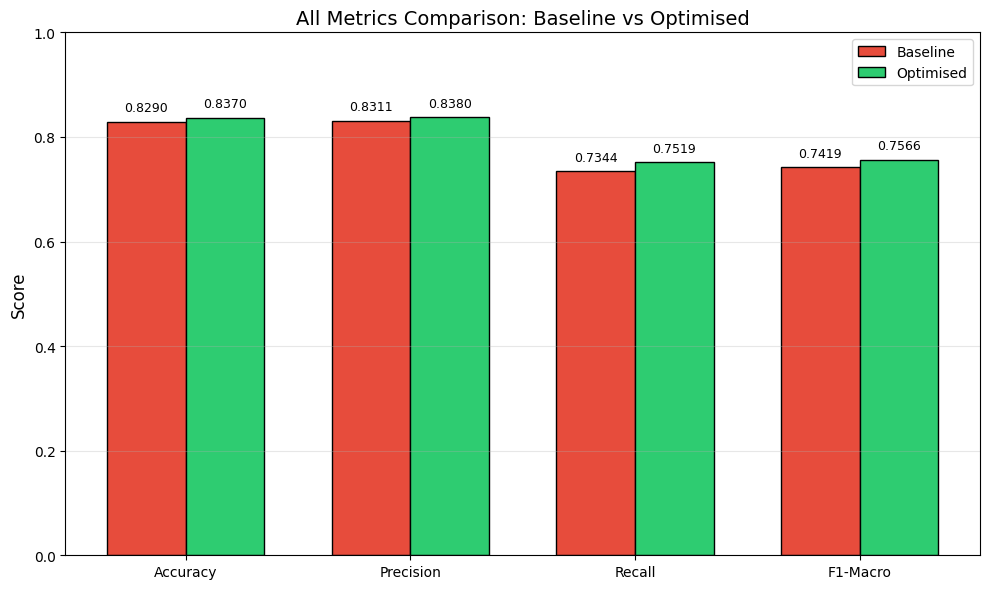

In [34]:
# Visualization 1: All Metrics Comparison (Baseline vs Optimised)
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
baseline_vals = [baseline_metrics[m] for m in metrics]
optimised_vals = [optimised_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, optimised_vals, width, label='Optimised', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics Comparison: Baseline vs Optimised', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

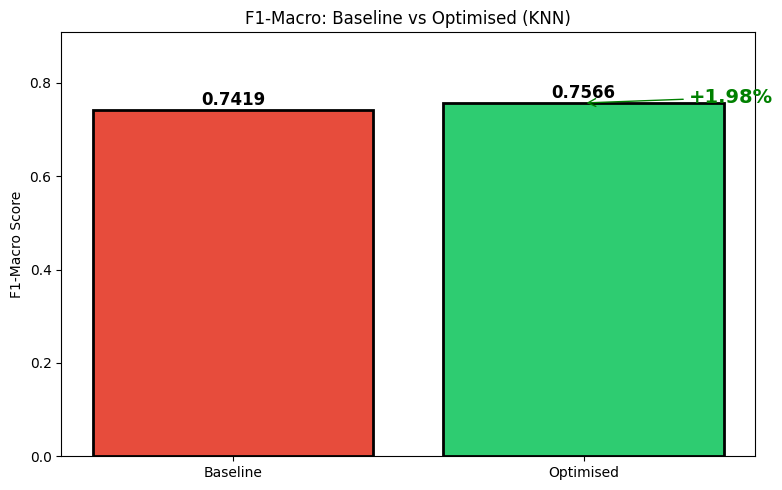

In [35]:
# F1 Score Comparison
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ['Baseline', 'Optimised']
f1_scores = [baseline_f1, optimised_f1]
colors = ['#e74c3c', '#2ecc71']

bars = ax.bar(strategies, f1_scores, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('F1-Macro Score')
ax.set_title(f'F1-Macro: Baseline vs Optimised ({selected_name})')
ax.set_ylim([0, max(f1_scores)*1.2])

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', fontsize=12, fontweight='bold')

improvement = ((optimised_f1 - baseline_f1) / baseline_f1) * 100
if improvement > 0:
    ax.annotate(f'+{improvement:.2f}%', xy=(1, optimised_f1), xytext=(1.3, optimised_f1),
                fontsize=14, fontweight='bold', color='green',
                arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

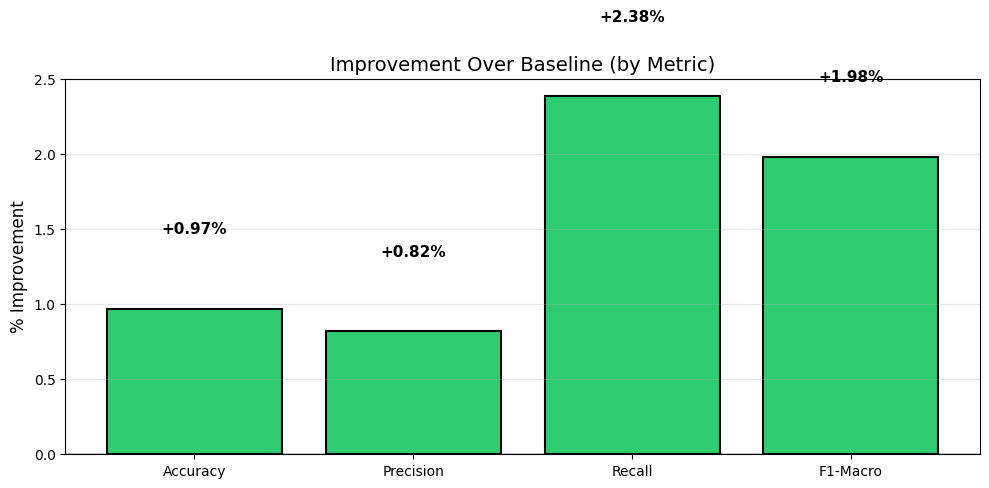

In [37]:
# Visualization 3: Improvement Percentage by Metric
improvements = []
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Macro']:
    base = baseline_metrics[metric]
    opt = optimised_metrics[metric]
    pct = ((opt - base) / base) * 100
    improvements.append(pct)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in improvements]
bars = ax.bar(metrics, improvements, color=colors, edgecolor='black', linewidth=1.5)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('% Improvement', fontsize=12)
ax.set_title('Improvement Over Baseline (by Metric)', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, improvements):
    y_pos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.2f}%', 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

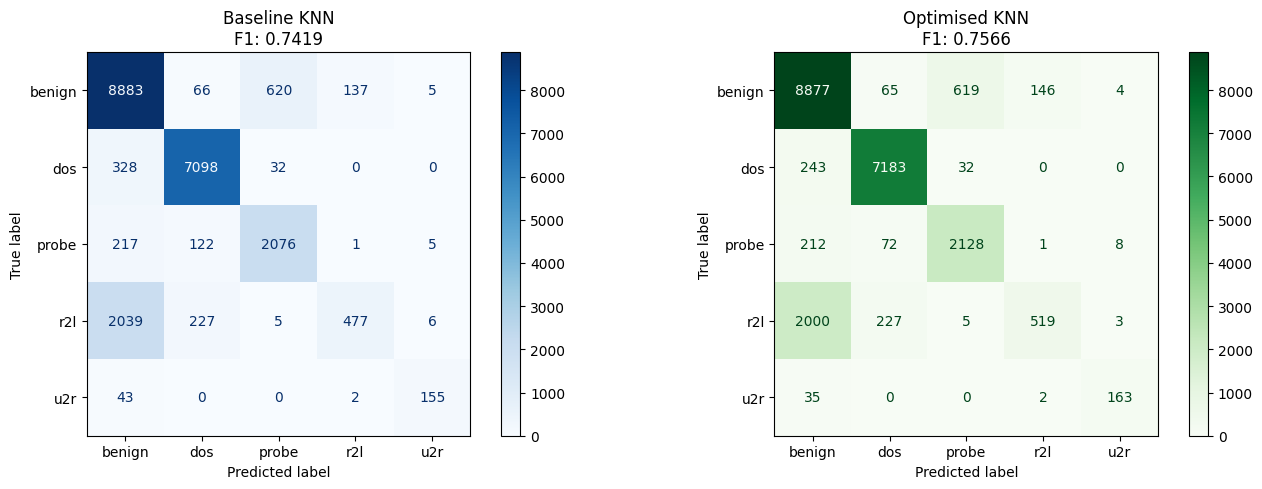

In [38]:
# Confusion Matrix: Baseline vs Optimised
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm1 = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm1, display_labels=best_clf.classes_).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Baseline {selected_name}\nF1: {baseline_f1:.4f}')

cm2 = confusion_matrix(y_test, y_pred_optimised)
ConfusionMatrixDisplay(cm2, display_labels=best_clf.classes_).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Optimised {selected_name}\nF1: {optimised_f1:.4f}')

plt.tight_layout()
plt.show()

***
### Conclusion

In [41]:
# ============================================================
# CONCLUSION
# ============================================================

print("="*65)
print("CONCLUSION")
print("="*65)

improvement = ((optimised_f1 - baseline_f1) / baseline_f1) * 100

# Dynamic justification based on classifier type
justifications = {
    'DecisionTree': """
  The optimised DecisionTree parameters improve generalization by:
  - 'splitter=random' introduces randomness at each split, preventing overfitting
  - 'max_depth' limits tree complexity, reducing variance
  - Better generalization to unseen test data and minority classes""",
    
    'KNN': """
  The optimised KNN parameters improve generalization by:
  - 'n_neighbors' balances bias-variance tradeoff (more neighbors = smoother boundaries)
  - 'weights=distance' gives closer neighbors more influence
  - 'metric' choice affects distance calculations in high-dimensional space""",
    
    'GaussianNB': """
  The optimised GaussianNB parameters improve generalization by:
  - 'var_smoothing' adds stability to variance estimates
  - Prevents division by zero for features with near-zero variance
  - Better handling of features with limited training samples"""
}

print(f"""
SELECTED CLASSIFIER: {selected_name}

BASELINE MODEL:
  - {selected_name} with default parameters
  - F1-Macro: {baseline_f1:.4f}

OPTIMISED MODEL:
  - Strategy: GridSearchCV (F1-Macro scoring)
  - Best Parameters: {grid_search.best_params_}
  - F1-Macro: {optimised_f1:.4f}

IMPROVEMENT: {improvement:+.2f}%

JUSTIFICATION:{justifications.get(selected_name, '''
  The optimised parameters improve generalization by:
  1. Reducing overfitting to training data
  2. Better handling of class imbalance
  3. Improved performance on minority classes (r2l, u2r)''')}
""")

CONCLUSION

SELECTED CLASSIFIER: KNN

BASELINE MODEL:
  - KNN with default parameters
  - F1-Macro: 0.7419

OPTIMISED MODEL:
  - Strategy: GridSearchCV (F1-Macro scoring)
  - Best Parameters: {'weights': 'distance'}
  - F1-Macro: 0.7566

IMPROVEMENT: +1.98%

JUSTIFICATION:
  The optimised KNN parameters improve generalization by:
  - 'n_neighbors' balances bias-variance tradeoff (more neighbors = smoother boundaries)
  - 'weights=distance' gives closer neighbors more influence
  - 'metric' choice affects distance calculations in high-dimensional space

